In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import sklearn
import pandas as pd
import os
import sys
import time
from tqdm.auto import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F

print(sys.version_info)
for module in mpl, np, pd, sklearn, torch:
    print(module.__name__, module.__version__)
    
device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
print(device)

seed = 42
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)


sys.version_info(major=3, minor=12, micro=3, releaselevel='final', serial=0)
matplotlib 3.10.8
numpy 2.4.0
pandas 2.3.3
sklearn 1.8.0
torch 2.9.1+cpu
cpu


In [3]:
# 由于无法上传imdb_processed.csv（分词和清洗后版本的IMDb数据），
# 我们采用datasets库直接加载IMDb原始数据集。
from datasets import load_dataset

# 加载IMDb数据集，包含train和test两个子集，train/test均有25000条影评，每条影评分为正面或负面（0/1）
dataset = load_dataset("imdb")

# 从训练集提取所有文本（影评内容）
# 解释语法:
# 这里，从datasets库加载imdb数据集后，dataset["train"]和dataset["test"]分别是训练集和测试集，
# 每一项为一个字典，包含"text"（评论内容）和"label"（标签：0=负面，1=正面）。
# 使用列表推导式 [item["text"] for item in dataset["train"]] 可以依次取出所有训练集的文本内容。

# datasets 返回的对象不是字典，而是 HuggingFace 提供的 DatasetDict 类型。
# 它的行为和字典类似，可以通过键（如 "train" 或 "test"）获取对应的数据集。
# 但是 dataset["train"] 的类型是 Dataset，它是 datasets 库自定义的数据集对象。
print(type(dataset))              # <class 'datasets.dataset_dict.DatasetDict'>
print(type(dataset["train"]))     # <class 'datasets.arrow_dataset.Dataset'>
print(dataset.keys())             # dict-like, 一般是 dict_keys(['train', 'test'])

train_texts = [item["text"] for item in dataset["train"]]

# 从测试集提取所有文本（影评内容）
test_texts = [item["text"] for item in dataset["test"]]

# 从训练集提取所有的标签（0为负面，1为正面）
train_labels = [item["label"] for item in dataset["train"]]

# 从测试集提取所有的标签（0为负面，1为正面）
test_labels = [item["label"] for item in dataset["test"]]

# 打印训练集和测试集的数量信息，便于确认数据集加载无误
print(f"训练集: {len(train_texts)}条, 测试集: {len(test_texts)}条")

# 将训练集的文本内容全部写入到imdb_train.txt文件，一行一个影评，字符全部转为小写
# 这样能减少后续分词的词表大小（因为大写变小写后"Love"与"love"不会被分为不同的token）
with open("imdb_train.txt", "w", encoding="utf8") as file:  # 保存训练集文本
    for line in train_texts:
        file.write(line.lower() + "\n")  # 写入小写文本，每行对应一个样本

# 将测试集的文本内容全部写入到imdb_test.txt文件，同样转换为小写后写入
with open("imdb_test.txt", "w", encoding="utf8") as file:   # 保存测试集文本
    for line in test_texts:
        file.write(line.lower() + "\n")

README.md: 0.00B [00:00, ?B/s]

d:\Programs\Python\Python312\Lib\site-packages\huggingface_hub\file_download.py:130: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\lenovo\.cache\huggingface\hub\datasets--imdb. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

<class 'datasets.dataset_dict.DatasetDict'>
<class 'datasets.arrow_dataset.Dataset'>
dict_keys(['train', 'test', 'unsupervised'])
训练集: 25000条, 测试集: 25000条


# 准备数据

这里使用subword分词，我们使用已经清洗好的数据集，可以从[此处](https://www.kaggleusercontent.com/kf/98352223/eyJhbGciOiJkaXIiLCJlbmMiOiJBMTI4Q0JDLUhTMjU2In0..nKt8lrIW5ej5QJQVpOWuqQ.oLIgiLMONU5Gpj_maVudRJa55NSOCILxk4JNZhvuXmeDBR-oG0uQm7bDHBfSwZRGvOBHQTsRV308iNP80btfwMinQ7yvJNt-GwdQF4XR4DIsg-2CbEPYiMsi_NdbL0FmE9LYStKdxCWbrCZCCMrTmo5LxR1txwibXaSpeP5Inobhbez5zetZIRH210CBuX2JbpRc_DULQpazKbtFPitwyfktVmdG_syvVAU6Sk9b0r0_erYAgb_jkKXX1Mxo1KzWSKLcAvbmMIPcsUkx9PmeJDs_wopfsQsZ1h5jaQX4_l0CTZrEenP6lIPDxpTwXANqqdHspmZeeEIAThqCHC6sb5DxTvG89BwzY9rc53Aa0uX4V806wJVybnRXoaV65K4GqpjnxbBK0WC8G-2lNtrqFujE89KDXZjFPgyfOEj1QIu13oFNSjgs6o4VV1PdZOrhiNdSmjb44c22l_unOaFojzJgzcPxq9AG2lcmrOpdZ2qu1jjdwey-58TA2ZHNCo3XnjEe2n3ignpnbsdLFpo22O8QakSUHv91wuYDYdNi3AiSmltL_k2ChuKfJ0G8kATpLe4k8wA26sO4GMXg4HImOr3b4aDVEIWXdApHP0ecFKs6ELTo8O7X-TK8Jvbua7e6qpDfDc-r_cD73fVSgSek5yNmKQMBzuVcjkprXmcxICQ.kV1b4N1s64NERKnt4zwQgQ/imdb_processed.csv)下载，分词使用 [subword-nmt](https://github.com/rsennrich/subword-nmt)

In [4]:
# 下面的代码用于训练和应用BPE (Byte Pair Encoding) 子词分词器，从而将文本切分为更细粒度、模型更易处理的子词单元。
# 这在处理自然语言任务时非常有用，尤其适合出现大量未知词或复合词的任务。
# 步骤如下：

# 1. 首先通过 learn-joint-bpe-and-vocab 命令，对 imdb_train.txt 训练集文本学习联合BPE规则以及词表，
#    输出分词规则(bpe_code)和词表(vocabulary)。这样可以获得适合当前文本数据的子词切分方式。
#    该过程较慢，只需运行一次即可。
!subword-nmt learn-joint-bpe-and-vocab -i ./imdb_train.txt -o ./imdb_bpe_code --write-vocabulary ./imdb_bpe_vocab -s 8000
# 参数说明：
#   -i：指定训练的语料文件（此处为训练集影评文本，已经全部小写化），是分词法学习的输入。
#   -o：分词规则（BPE编码规则）输出路径，后续实际分词时需要使用这个文件。
#   --write-vocabulary：输出子词词汇表，便于后续查看BPE后的词汇。
#   -s：指定BPE合并操作次数，即词表大小。这里设置为8000，表示最大词汇量为8000（子词级别）。

# 2. 用刚刚学到的 BPE 分词规则分别对训练集（imdb_train.txt）和测试集（imdb_test.txt）文本文件进行切分，
#    得到bpe分词后的文本结果（每个单词可能被拆成更细粒度的若干子词，结尾用@@标记，便于模型处理）。
#    这样既可有效覆盖低频词，又减少了词表大小，提升了模型泛化能力。
!subword-nmt apply-bpe -c ./imdb_bpe_code -i ./imdb_train.txt -o ./imdb_train_bpe.txt
!subword-nmt apply-bpe -c ./imdb_bpe_code -i ./imdb_test.txt -o ./imdb_test_bpe.txt
# 参数说明：
#   -c：指定分词时所用的BPE规则文件（即第一步输出的 imdb_bpe_code）
#   -i：输入原始文本（分别为训练集和测试集）
#   -o：输出分词后的文本文件，每行对应一条影评，其中词被BPE子词分隔


100%|##########| 8000/8000 [00:40<00:00, 196.40it/s]


In [5]:
# 分词后的数据长什么样
!head ./imdb_train_bpe.txt
# @@ 是分词的标记

i rented i am curi@@ ous@@ -@@ yel@@ low from my video store because of all the controver@@ sy that surrounded it when it was first released in 196@@ 7. i also heard that at first it was se@@ i@@ zed by u.s. cu@@ stom@@ s if it ever tried to enter this countr@@ y, therefore being a fan of films considered "@@ controversi@@ al" i really had to see this for my@@ self.<br /><br />the plot is cent@@ ered around a young swe@@ dish drama student named len@@ a who wants to learn everything she can about life. in particular she wants to focus her atten@@ tions to making some sort of documentary on what the average sw@@ ed@@ e thought about certain political issues such as the vietnam war and race issues in the united stat@@ es. in between asking polit@@ ici@@ ans and ordinary den@@ iz@@ ens of sto@@ ck@@ hol@@ m about their opini@@ ons on polit@@ ics, she has sex with her drama teac@@ her, class@@ mat@@ es, and married men@@ .<br /><br />what kills me about i am curi@@ ous@@ -@@ yel@@ low is t

In [7]:
# 1. 创建一个空列表用于保存所有BPE分词（含训练集和测试集的子词序列）
subwords = []

# 2. 依次读取处理好的训练集分词文件，每行为一条影评（经过BPE编码后的子词序列），去除首尾空白后加入subwords列表
with open("imdb_train_bpe.txt", "r", encoding="utf8") as file:
    for line in file.readlines():
        subwords.append(line.strip())  # .strip()移除每行末尾换行符

# 3. 同理读取处理好的测试集分词文件，追加到subwords列表后面
with open("imdb_test_bpe.txt", "r", encoding="utf8") as file:
    for line in file.readlines():
        subwords.append(line.strip())

# 4. 构建一个pandas DataFrame，保存清洗和分词后的数据，便于后续加载和处理
#   - "subwords10k" 列保存分词好的文本内容（字符串，子词用空格分隔，每行代表一条影评）
#   - "label"        列保存影评的情感标签（train_labels和test_labels已经提前准备好，按顺序拼接）
#   - "split"        列标记数据属于训练集("train")还是测试集("test")
cleaned_df = pd.DataFrame({
    "subwords10k": subwords,                                  # 子词级影评文本
    "label": train_labels + test_labels,                      # 标签，列表拼接保证顺序和影评对应
    "split": ["train"] * len(train_texts) +                   # 前len(train_texts)行为"train"
             ["test"] * len(test_texts)                       # 后len(test_texts)行为"test"
})

# 5. 将带有分词结果和标签的数据表存储为CSV文件，便于后续随时按需加载使用
cleaned_df.to_csv("imdb_subwords.csv", index=False)           # 不保留行索引

In [8]:
cleaned_df.head()

,subwords10k,label,split
0,i rented i am curi@@ ous@@ -@@ yel@@ low from ...,0,train
1,"""i am curi@@ ous@@ : yel@@ low@@ "" is a ri@@ s...",0,train
2,if only to avoid making this type of film in t...,0,train
3,this film was probably inspired by go@@ dar@@ ...,0,train
4,"oh, brother@@ ...@@ after hearing about this r...",0,train


In [11]:
from torch.utils.data import Dataset, DataLoader

# 定义自定义的数据集类，用于加载BPE分词后的IMDB影评数据
class IMDBDataset(Dataset):
    def __init__(self, mode="train"):
        """
        初始化函数
        参数:
            mode: 指定加载训练集("train")还是测试集("test")
        功能:
            - 加载保存分词内容和标签的CSV文件
            - 按split字段过滤，获得指定mode的数据子集
            - 保存分词文本和标签字段为成员变量
        """
        # 读取CSV，将"split"列为指定mode的数据筛选出来
        df = pd.read_csv("imdb_subwords.csv").query("split == '{}'".format(mode)) # 加载训练集或测试集，query语句筛选
        # 取出数据表中的分词文本（"subwords10k"列），以numpy数组形式保存
        self.texts = df["subwords10k"].values # 影评文本，每条为已经用空格分割的子词序列字符串
        # 取出情感标签（同上）
        self.labels = df["label"].values      # 影评标签 0/1
        
    def __len__(self):
        """
        返回数据集的样本数量
        """
        return len(self.labels)
    
    def __getitem__(self, idx):
        """
        返回指定索引的样本: (子词序列, 标签)
        - 文本通过空格split处理成子词列表
        - 对应的标签直接返回
        """
        return self.texts[idx].split(), self.labels[idx] # 返回分词后的文本（子词列表）和标签

# 实例化训练集和测试集
train_ds = IMDBDataset("train") # 加载训练集
test_ds = IMDBDataset("test")   # 加载测试集

In [ ]:
train_ds[0]

(['i',
  'rented',
  'i',
  'am',
  'curi@@',
  'ous@@',
  '-@@',
  'yel@@',
  'low',
  'from',
  'my',
  'video',
  'store',
  'because',
  'of',
  'all',
  'the',
  'controver@@',
  'sy',
  'that',
  'surrounded',
  'it',
  'when',
  'it',
  'was',
  'first',
  'released',
  'in',
  '196@@',
  '7.',
  'i',
  'also',
  'heard',
  'that',
  'at',
  'first',
  'it',
  'was',
  'se@@',
  'i@@',
  'zed',
  'by',
  'u.s.',
  'cu@@',
  'stom@@',
  's',
  'if',
  'it',
  'ever',
  'tried',
  'to',
  'enter',
  'this',
  'countr@@',
  'y,',
  'therefore',
  'being',
  'a',
  'fan',
  'of',
  'films',
  'considered',
  '"@@',
  'controversi@@',
  'al"',
  'i',
  'really',
  'had',
  'to',
  'see',
  'this',
  'for',
  'my@@',
  'self.<br',
  '/><br',
  '/>the',
  'plot',
  'is',
  'cent@@',
  'ered',
  'around',
  'a',
  'young',
  'swe@@',
  'dish',
  'drama',
  'student',
  'named',
  'len@@',
  'a',
  'who',
  'wants',
  'to',
  'learn',
  'everything',
  'she',
  'can',
  'about',
  'life.

## 构造 word2idx 和 idx2word

In [9]:
# 加载BPE子词词表，并构建word2idx和idx2word映射
# word2idx: 子词 -> 索引    idx2word: 索引 -> 子词

# 初始化特殊token，并指定在词表中的固定索引
word2idx = {
    "[PAD]": 0,     # 用于句子长度补齐的填充token
    "[BOS]": 1,     # 句子开始的标志(begin of sentence)
    "[UNK]": 2,     # 未知token，未登录的词用此表示
    "[EOS]": 3,     # 句子结束的标志(end of sentence)
}

# 构建反向字典，用于索引->子词的反查
idx2word = {value: key for key, value in word2idx.items()}

# 打印一下当前idx2word，主要是4个特殊token
print(idx2word)

# 当前词表已包含4个特殊token，后续实际子词从索引4开始添加
index = len(idx2word) # index=4

# 词频阈值，低于该频次的token将被丢弃（常用于过滤罕见子词）
threshold = 1

# 逐行读取BPE词表(imdb_bpe_vocab)，每行为"token 频次"
with open("imdb_bpe_vocab", "r", encoding="utf8") as file:
    for line in tqdm(file.readlines()):
        temp = line.strip().split() # 去除首尾空白并按空格切分
        if len(temp) != 2:
            # 如果不符合"token 频次"格式，输出内容并跳过
            print(temp)
            continue
        token, counts = temp
        # 只保留频次>=threshold的token
        if int(counts) >= threshold:
            word2idx[token] = index  # 子词添加到word2idx（子词->索引）
            idx2word[index] = token  # 索引添加到idx2word（索引->子词）
            index += 1               # 索引自增，为下一个词分配新id

# 统计词表总长度（含特殊token和全部保留的子词）
vocab_size = len(word2idx)
print("vocab_size: {}".format(vocab_size))

{0: '[PAD]', 1: '[BOS]', 2: '[UNK]', 3: '[EOS]'}


  0%|          | 0/8230 [00:00<?, ?it/s]

['707']
['2']
vocab_size: 8230


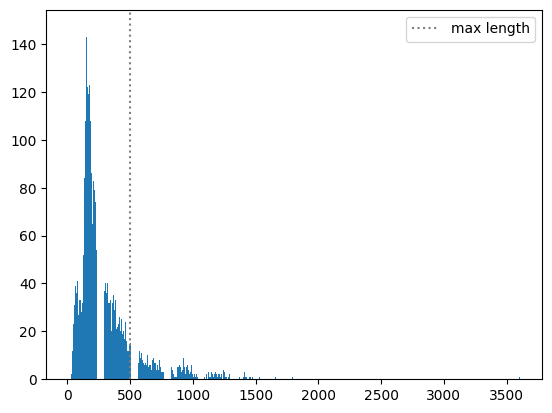

In [12]:
# 选择 max_length
length_collect = {}
for text, label in train_ds:
    length = len(text)
    length_collect[length] = length_collect.get(length, 0) + 1
    
MAX_LENGTH = 500
plt.bar(length_collect.keys(), length_collect.values())
plt.axvline(MAX_LENGTH, label="max length", c="gray", ls=":")
plt.legend()
plt.show()

## Tokenizer

In [13]:
class Tokenizer:
    def __init__(self, word2idx, idx2word, max_length=500, pad_idx=0, bos_idx=1, eos_idx=3, unk_idx=2):
        """
        Tokenizer类，用于子词级别的编码与解码。

        参数:
            word2idx: dict, 子词到索引的映射
            idx2word: dict, 索引到子词的映射
            max_length: int, 句子最大长度，超过该长度的句子将被截断
            pad_idx: int, PAD的索引
            bos_idx: int, BOS的索引
            eos_idx: int, EOS的索引
            unk_idx: int, UNK的索引
        """
        self.word2idx = word2idx           # 子词->索引 映射
        self.idx2word = idx2word           # 索引->子词 映射
        self.max_length = max_length       # 最大句长
        self.pad_idx = pad_idx             # 填充词索引
        self.bos_idx = bos_idx             # 句子开始符索引
        self.eos_idx = eos_idx             # 句子结束符索引
        self.unk_idx = unk_idx             # 未登录词索引
    
    def encode(self, text_list, padding_first=False):
        """
        将分词后的句子批量编码为索引（数字）张量，支持自动加BOS/EOS和自动padding。
        
        参数:
            text_list: list of list of str, 多个分词后的句子（例如[['hello','world'], ['i','am','happy']]）
            padding_first: bool, 是否把padding加在序列前面（True：padding在前，False：padding在后）
        
        返回:
            shape=[len(text_list), 序列长度] 的LongTensor
        """
        # 句子总长度，包括BOS和EOS各1，所以+2
        max_length = min(self.max_length, 2 + max([len(text) for text in text_list]))
        indices_list = []
        for text in text_list:
            # (1) 句子前加BOS (2) 文本转索引，不在词表的用UNK (3) 句子后加EOS
            indices = [self.bos_idx] + [self.word2idx.get(word, self.unk_idx) for word in text[:max_length-2]] + [self.eos_idx]
            # padding到max_length长度
            if padding_first:
                # padding加载序列最前面
                indices = [self.pad_idx] * (max_length - len(indices)) + indices
            else:
                # padding加载序列最后面
                indices = indices + [self.pad_idx] * (max_length - len(indices))
            indices_list.append(indices)
        # 转换为pytorch tensor
        return torch.tensor(indices_list)

    def decode(self, indices_list, remove_bos=True, remove_eos=True, remove_pad=True, split=False):
        """
        将索引序列批量还原为字符串（句子），支持去除特殊符号BOS/EOS/PAD。

        参数:
            indices_list: list of list of int, 多个句子的索引序列
            remove_bos: bool, 是否去掉[BOS]
            remove_eos: bool, 是否碰到[EOS]提前终止
            remove_pad: bool, 是否碰到[PAD]提前终止
            split: bool, 如果为True则返回分词结果，否则返回拼接的最终句子字符串

        返回:
            text_list: 还原后的每个句子的字符串或分词列表
        """
        text_list = []
        for indices in indices_list:
            text = []
            for index in indices:
                word = self.idx2word.get(index, "[UNK]")  # 用[UNK]替换未登录词
                if remove_bos and word == "[BOS]":
                    continue           # 跳过BOS
                if remove_eos and word == "[EOS]":
                    break              # 提前遇到EOS则截断后续
                if remove_pad and word == "[PAD]":
                    break              # 提前遇到PAD则截断后续
                text.append(word)
            # split=False返回句子字符串，True返回子词list
            text_list.append(" ".join(text) if not split else text)
        return text_list

# 测试Tokenizer类的用法及其效果
tokenizer = Tokenizer(word2idx=word2idx, idx2word=idx2word)

# 原始输入（每个句子为分好词的list）
raw_text = [
    "hello world".split(),
    "tokenize text datas with batch".split(),
    "this is a test".split()
]

# 编码：将分词后的句子转为token id
indices = tokenizer.encode(raw_text, padding_first=False)

# 解码：将token id再转回token串，取消去除特殊符号以便查看效果
decode_text = tokenizer.decode(indices.tolist(), remove_bos=False, remove_eos=False, remove_pad=False)

print("raw text")
for raw in raw_text:
    print(raw)
print("indices")
for index in indices:
    print(index)
print("decode text")
for decode in decode_text:
    print(decode)

raw text
['hello', 'world']
['tokenize', 'text', 'datas', 'with', 'batch']
['this', 'is', 'a', 'test']
indices
tensor([  1,   2, 410,   3,   0,   0,   0])
tensor([ 1,  2,  2,  2, 19,  2,  3])
tensor([   1,   12,    9,    5, 4144,    3,    0])
decode text
[BOS] [UNK] world [EOS] [PAD] [PAD] [PAD]
[BOS] [UNK] [UNK] [UNK] with [UNK] [EOS]
[BOS] this is a test [EOS] [PAD]


In [ ]:
def collate_fct(batch):
    """
    把字符串列表转化为tensor
    :param batch:
    :return:
    """
    text_list = [item[0] for item in batch] #batch中每个item的第一个元素是text,是输入，类型为list
    label_list = [item[1] for item in batch] #batch中每个item的第二个元素是label,是输出，类型为int
    # 这里使用 padding first
    text_list = tokenizer.encode(text_list, padding_first=True).to(dtype=torch.int)
    return text_list, torch.tensor(label_list).reshape(-1, 1).to(dtype=torch.float)

batch_size = 128
train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True, collate_fn=collate_fct)
test_dl = DataLoader(test_ds, batch_size=batch_size, shuffle=False, collate_fn=collate_fct)

# 定义模型

In [ ]:
class LSTM(nn.Module):
    def __init__(self, embedding_dim=16, hidden_dim=64, vocab_size=vocab_size, num_layers=1, bidirectional=False):
        super(LSTM, self).__init__()
        self.embeding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, num_layers=num_layers, batch_first=True, bidirectional=bidirectional)
        self.layer = nn.Linear(hidden_dim * (2 if bidirectional else 1), hidden_dim)
        self.fc = nn.Linear(hidden_dim, 1)
        
    def forward(self, x):
        # [bs, seq length]
        x = self.embeding(x)
        # [bs, seq length, embedding_dim] -> shape [bs, embedding_dim, seq length]
        seq_output, (hidden, cell) = self.lstm(x)
        # [bs, seq length, hidden_dim], [*, bs, hidden_dim]
        x = seq_output[:, -1, :]
        # 取最后一个时间步的输出 (这也是为什么要设置padding_first=True的原因)
        x = self.layer(x)
        x = self.fc(x)
        return x
    
sample_inputs = torch.randint(0, vocab_size, (2, 128))
    
print("{:=^80}".format(" 一层单向 LSTM "))       
for key, value in LSTM().named_parameters():
    print(f"{key:^40}paramerters num: {np.prod(value.shape)}")

    
print("{:=^80}".format(" 一层双向 LSTM "))       
for key, value in LSTM(bidirectional=True).named_parameters():
    print(f"{key:^40}paramerters num: {np.prod(value.shape)}")

    
print("{:=^80}".format(" 两层单向 LSTM "))       
for key, value in LSTM(num_layers=2).named_parameters():
    print(f"{key:^40}paramerters num: {np.prod(value.shape)}")


================================== 一层单向 LSTM ===================================
            embeding.weight             paramerters num: 26000
           lstm.weight_ih_l0            paramerters num: 4096
           lstm.weight_hh_l0            paramerters num: 16384
            lstm.bias_ih_l0             paramerters num: 256
            lstm.bias_hh_l0             paramerters num: 256
              layer.weight              paramerters num: 4096
               layer.bias               paramerters num: 64
               fc.weight                paramerters num: 64
                fc.bias                 paramerters num: 1
================================== 一层双向 LSTM ===================================
            embeding.weight             paramerters num: 26000
           lstm.weight_ih_l0            paramerters num: 4096
           lstm.weight_hh_l0            paramerters num: 16384
            lstm.bias_ih_l0             paramerters num: 256
            lstm.bias_hh_l0           

# 训练

In [ ]:
from sklearn.metrics import accuracy_score

@torch.no_grad()
def evaluating(model, dataloader, loss_fct):
    loss_list = []
    pred_list = []
    label_list = []
    for datas, labels in dataloader:
        datas = datas.to(device)
        labels = labels.to(device)
        # 前向计算
        logits = model(datas)
        loss = loss_fct(logits, labels)         # 验证集损失
        loss_list.append(loss.item())
        # 二分类
        preds = logits > 0
        pred_list.extend(preds.cpu().numpy().tolist())
        label_list.extend(labels.cpu().numpy().tolist())
        
    acc = accuracy_score(label_list, pred_list)
    return np.mean(loss_list), acc


### Save Best


In [ ]:
class SaveCheckpointsCallback:
    def __init__(self, save_dir, save_step=5000, save_best_only=True):
        """
        Save checkpoints each save_epoch epoch. 
        We save checkpoint by epoch in this implementation.
        Usually, training scripts with pytorch evaluating model and save checkpoint by step.

        Args:
            save_dir (str): dir to save checkpoint
            save_epoch (int, optional): the frequency to save checkpoint. Defaults to 1.
            save_best_only (bool, optional): If True, only save the best model or save each model at every epoch.
        """
        self.save_dir = save_dir
        self.save_step = save_step
        self.save_best_only = save_best_only
        self.best_metrics = -1
        
        # mkdir
        if not os.path.exists(self.save_dir):
            os.mkdir(self.save_dir)
        
    def __call__(self, step, state_dict, metric=None):
        if step % self.save_step > 0:
            return
        
        if self.save_best_only:
            assert metric is not None
            if metric >= self.best_metrics:
                # save checkpoints
                torch.save(state_dict, os.path.join(self.save_dir, "best.ckpt"))
                # update best metrics
                self.best_metrics = metric
        else:
            torch.save(state_dict, os.path.join(self.save_dir, f"{step}.ckpt"))



### Early Stop

In [ ]:
class EarlyStopCallback:
    def __init__(self, patience=5, min_delta=0.01):
        """

        Args:
            patience (int, optional): Number of epochs with no improvement after which training will be stopped.. Defaults to 5.
            min_delta (float, optional): Minimum change in the monitored quantity to qualify as an improvement, i.e. an absolute 
                change of less than min_delta, will count as no improvement. Defaults to 0.01.
        """
        self.patience = patience
        self.min_delta = min_delta
        self.best_metric = -1
        self.counter = 0
        
    def __call__(self, metric):
        if metric >= self.best_metric + self.min_delta:
            # update best metric
            self.best_metric = metric
            # reset counter 
            self.counter = 0
        else: 
            self.counter += 1
            
    @property
    def early_stop(self):
        return self.counter >= self.patience


In [ ]:
# 训练
def training(
    model, 
    train_loader, 
    val_loader, 
    epoch, 
    loss_fct, 
    optimizer, 
    tensorboard_callback=None,
    save_ckpt_callback=None,
    early_stop_callback=None,
    eval_step=500,
    ):
    record_dict = {
        "train": [],
        "val": []
    }
    
    global_step = 0
    model.train()
    with tqdm(total=epoch * len(train_loader)) as pbar:
        for epoch_id in range(epoch):
            # training
            for datas, labels in train_loader:
                datas = datas.to(device)
                labels = labels.to(device)
                # 梯度清空
                optimizer.zero_grad()
                # 模型前向计算
                logits = model(datas)
                # 计算损失
                loss = loss_fct(logits, labels)
                # 梯度回传
                loss.backward()
                # 调整优化器，包括学习率的变动等
                optimizer.step()
                preds = logits > 0
            
                acc = accuracy_score(labels.cpu().numpy(), preds.cpu().numpy())    
                loss = loss.cpu().item()
                # record
                
                record_dict["train"].append({
                    "loss": loss, "acc": acc, "step": global_step
                })
                
                # evaluating
                if global_step % eval_step == 0:
                    model.eval()
                    val_loss, val_acc = evaluating(model, val_loader, loss_fct)
                    record_dict["val"].append({
                        "loss": val_loss, "acc": val_acc, "step": global_step
                    })
                    model.train()
                    
                    # 1. 使用 tensorboard 可视化
                    if tensorboard_callback is not None:
                        tensorboard_callback(
                            global_step, 
                            loss=loss, val_loss=val_loss,
                            acc=acc, val_acc=val_acc,
                            lr=optimizer.param_groups[0]["lr"],
                            )
                
                    # 2. 保存模型权重 save model checkpoint
                    if save_ckpt_callback is not None:
                        save_ckpt_callback(global_step, model.state_dict(), metric=val_acc)

                    # 3. 早停 Early Stop
                    if early_stop_callback is not None:
                        early_stop_callback(val_acc)
                        if early_stop_callback.early_stop:
                            print(f"Early stop at epoch {epoch_id} / global_step {global_step}")
                            return record_dict
                    
                # udate step
                global_step += 1
                pbar.update(1)
                pbar.set_postfix({"epoch": epoch_id})
        
    return record_dict
        

epoch = 20

model = LSTM()

# 1. 定义损失函数 采用交叉熵损失 (但是二分类)
loss_fct = F.binary_cross_entropy_with_logits
# 2. 定义优化器 采用 adam
# Optimizers specified in the torch.optim package
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# 1. tensorboard 可视化
if not os.path.exists("runs"):
    os.mkdir("runs")


# 2. save best
if not os.path.exists("checkpoints"):
    os.makedirs("checkpoints")
save_ckpt_callback = SaveCheckpointsCallback("checkpoints/imdb-lstm-subword", save_step=len(train_dl), save_best_only=True)
# 3. early stop
early_stop_callback = EarlyStopCallback(patience=10)

model = model.to(device)
record = training(
    model, 
    train_dl, 
    test_dl, 
    epoch, 
    loss_fct, 
    optimizer, 
    tensorboard_callback=None,
    save_ckpt_callback=save_ckpt_callback,
    early_stop_callback=early_stop_callback,
    eval_step=len(train_dl)
    )

  0%|          | 0/3920 [00:00<?, ?it/s]

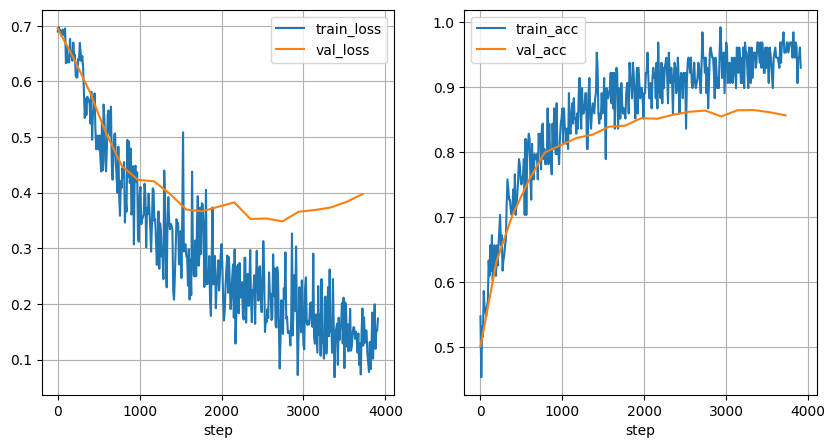

In [ ]:
#画线要注意的是损失是不一定在零到1之间的
def plot_learning_curves(record_dict, sample_step=500):
    # build DataFrame
    train_df = pd.DataFrame(record_dict["train"]).set_index("step").iloc[::sample_step]
    val_df = pd.DataFrame(record_dict["val"]).set_index("step")

    # plot
    fig_num = len(train_df.columns)
    fig, axs = plt.subplots(1, fig_num, figsize=(5 * fig_num, 5))
    for idx, item in enumerate(train_df.columns):    
        axs[idx].plot(train_df.index, train_df[item], label=f"train_{item}")
        axs[idx].plot(val_df.index, val_df[item], label=f"val_{item}")
        axs[idx].grid()
        axs[idx].legend()
        # axs[idx].set_xticks(range(0, train_df.index[-1], 5000))
        # axs[idx].set_xticklabels(map(lambda x: f"{int(x/1000)}k", range(0, train_df.index[-1], 5000)))
        axs[idx].set_xlabel("step")
    
    plt.show()

plot_learning_curves(record, sample_step=10)  #横坐标是 steps

# 评估

In [ ]:
# dataload for evaluating

# load checkpoints
model.load_state_dict(torch.load("checkpoints/imdb-lstm-subword/best.ckpt", map_location="cpu"))

model.eval()
loss, acc = evaluating(model, test_dl, loss_fct)
print(f"loss:     {loss:.4f}\naccuracy: {acc:.4f}")

loss:     0.3734
accuracy: 0.8647
